In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-data/mitbih_test.csv
/kaggle/input/ecg-data/mitbih_train.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
train_df = pd.read_csv("/kaggle/input/ecg-data/mitbih_test.csv")
test_df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv")

In [4]:
total_samples = train_df.shape[0] + test_df.shape[0]
total_samples

109444

#### The paper says total samples is **109,446** but what I found is **109444** samples

In [5]:
df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv", header=None)

In [6]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.shape

(87554, 188)

In [8]:
display(df.describe)

<bound method NDFrame.describe of             0         1         2         3         4         5         6    \
0      0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1      0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2      1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3      0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4      0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   
...         ...       ...       ...       ...       ...       ...       ...   
87549  0.807018  0.494737  0.536842  0.529825  0.491228  0.484211  0.456140   
87550  0.718333  0.605000  0.486667  0.361667  0.231667  0.120000  0.051667   
87551  0.906122  0.624490  0.595918  0.575510  0.530612  0.481633  0.444898   
87552  0.858228  0.645570  0.845570  0.248101  0.167089  0.131646  0.121519   
87553  0.901506  0.845886  0.800695  0.748552  0.687138  0.599073  0.512167   

            7    

In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

In [10]:
print(X.shape)
print(y.unique())

(87554, 187)
[0. 1. 2. 3. 4.]


In [11]:
y.value_counts()

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

In [12]:
label_y = {
    0:"N (Normal)",
    1:"S (Supraventricular)",
    2:"V (Ventricular)",
    3: "F (Fusion)",
    4: "Q (Unknown)"
}

y.value_counts().rename(index=label_y)

187
N (Normal)              72471
Q (Unknown)              6431
V (Ventricular)          5788
S (Supraventricular)     2223
F (Fusion)                641
Name: count, dtype: int64

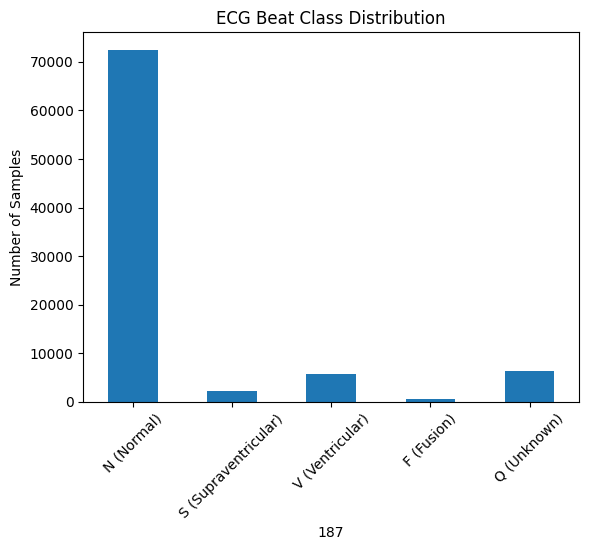

In [13]:
import matplotlib.pyplot as plt

y.value_counts().sort_index().plot(kind='bar')
plt.xticks(range(5), label_y.values(), rotation=45)
plt.title("ECG Beat Class Distribution")
plt.ylabel("Number of Samples")
plt.show()


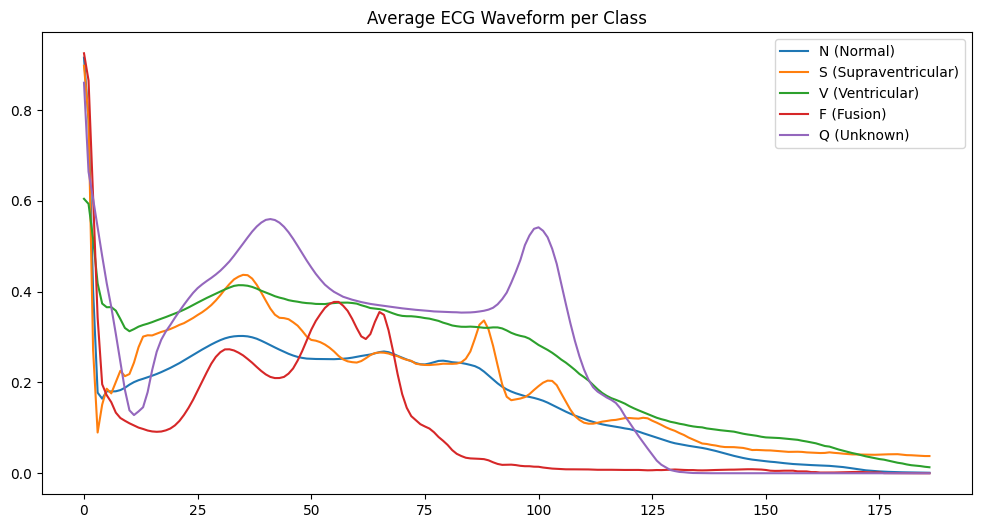

In [14]:
plt.figure(figsize=(12,6))
for cls in range(5):
    mean_wave = X[y == cls].mean(axis=0)
    plt.plot(mean_wave, label=label_y[cls])

plt.title("Average ECG Waveform per Class")
plt.legend()
plt.show()


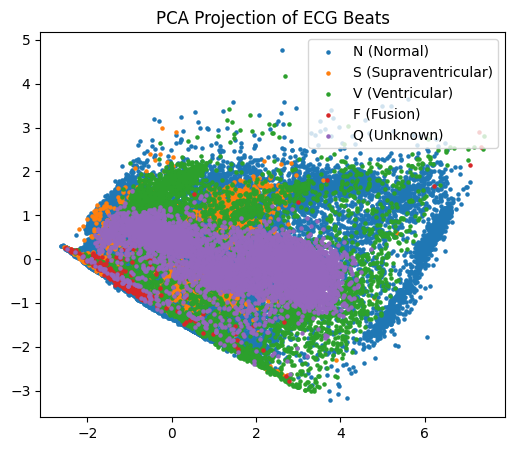

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
for cls in range(5):
    plt.scatter(
        X_pca[y==cls, 0],
        X_pca[y==cls, 1],
        label=label_y[cls],
        s=5
    )
plt.legend()
plt.title("PCA Projection of ECG Beats")
plt.show()


In [16]:
signal = X.iloc[0].values

In [17]:
def add_gaussian_noise(signal, mean=0, std=0.02):
    noise = np.random.normal(mean, std, size=signal.shape)
    noisy_signal = signal+ noise
    return noisy_signal

In [18]:
noisy_signal = add_gaussian_noise(signal)

In [19]:
def mva(signal, window_size=5):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

In [20]:
denoised_signal = mva(noisy_signal)

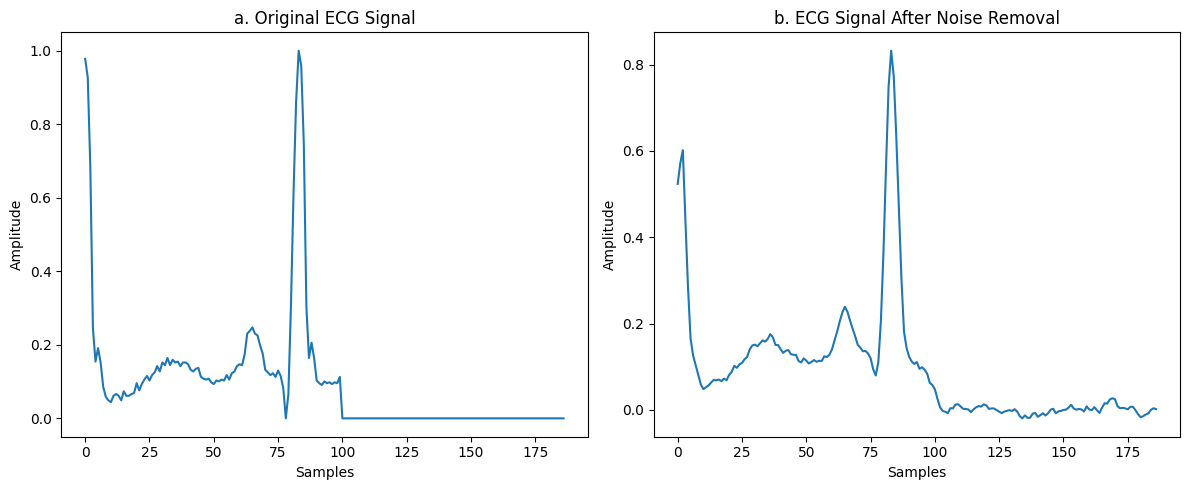

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(signal)
plt.title("a. Original ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")


plt.subplot(1, 2, 2)
plt.plot(denoised_signal)
plt.title("b. ECG Signal After Noise Removal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Activation, Flatten, Dense, Input
)


2026-01-06 15:43:48.141521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767714228.309041      26 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767714228.361383      26 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767714228.775693      26 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767714228.775743      26 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767714228.775746      26 computation_placer.cc:177] computation placer alr

In [23]:
num_classes = 5
input_shape = (187, 1)

In [24]:
model = Sequential([
    Input(shape=input_shape),

   
    Conv1D(filters=64, kernel_size=6, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=3, strides=2, padding='same'),

    
    Conv1D(filters=64, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'),

    
    Conv1D(filters=64, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'),

    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

I0000 00:00:1767714240.550921      26 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 47, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,613 (486.77 KB)

 Trainable params: 124,229 (485.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## RESNET

In [27]:
from tensorflow.keras.layers import Add

def residual_block(x, filters, kernel_size=3):
    shortcut = x

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)

    return x


In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling1D

inputs = Input(shape=(187, 1))


x = Conv1D(64, kernel_size=6, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)


x = residual_block(x, filters=64)
x = MaxPooling1D(pool_size=2, strides=2, padding='same')(x)


x = residual_block(x, filters=64)
x = MaxPooling1D(pool_size=2, strides=2, padding='same')(x)


x = GlobalAveragePooling1D()(x)
outputs = Dense(num_classes, activation='softmax')(x)

resnet_1d = Model(inputs, outputs)

resnet_1d.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 187, 64)   │        448 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 187, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 187, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 94, 64)    │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 94, 64)    │     12,352 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 94, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 94, 64)    │     12,352 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 94, 64)    │          0 │ max_pooling1d_3[… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 94, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 47, 64)    │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 47, 64)    │     12,352 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 47, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 47, 64)    │     12,352 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 51,461 (201.02 KB)

 Trainable params: 50,821 (198.52 KB)

 Non-trainable params: 640 (2.50 KB)

In [29]:
resnet_1d.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
import numpy as np
from sklearn.model_selection import train_test_split

# Convert to numpy
X_np = X.values.reshape(-1, 187, 1)
y_np = y.values

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, Input

num_classes = 5

lstm_model = Sequential([
    Input(shape=(187,1)),
    
    LSTM(64, return_sequences=True),
    Flatten(),
    
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 187, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11968)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       766,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785,157 (3.00 MB)

 Trainable params: 785,157 (3.00 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20


I0000 00:00:1767714244.891970      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


548/548 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8699 - loss: 0.4747 - val_accuracy: 0.9521 - val_loss: 0.1749
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9566 - loss: 0.1650 - val_accuracy: 0.9633 - val_loss: 0.1309
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9654 - loss: 0.1250 - val_accuracy: 0.9690 - val_loss: 0.1115
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9695 - loss: 0.1075 - val_accuracy: 0.9703 - val_loss: 0.1019
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9733 - loss: 0.0921 - val_accuracy: 0.9726 - val_loss: 0.0996
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9757 - loss: 0.0856 - val_accuracy: 0.9744 - val_loss: 0.0973
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9780 - loss: 0.0758 - val_accuracy: 0.9773 - val_loss: 0.0813
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9795 - loss: 0.0694 - val_accuracy: 0.97

In [33]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    Input(shape=(187,1)),
    
    Bidirectional(LSTM(64, return_sequences=True)),
    Flatten(),
    
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 187, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 23936)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,531,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,005 (5.98 MB)

 Trainable params: 1,568,005 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_bilstm = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8747 - loss: 0.4647 - val_accuracy: 0.9540 - val_loss: 0.1788
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9575 - loss: 0.1618 - val_accuracy: 0.9661 - val_loss: 0.1258
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9658 - loss: 0.1263 - val_accuracy: 0.9674 - val_loss: 0.1143
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9703 - loss: 0.1058 - val_accuracy: 0.9705 - val_loss: 0.1055
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9730 - loss: 0.0935 - val_accuracy: 0.9731 - val_loss: 0.0956
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9761 - loss: 0.0811 - val_accuracy: 0.9765 - val_loss: 0.0848
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9778 - loss: 0.0761 - val_accuracy: 0.9761 - val_loss: 0.0838
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9801 - loss: 0.0659 - 

In [35]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, accuracy_score,
    mean_absolute_error, log_loss
)

# LSTM
y_pred_lstm = np.argmax(lstm_model.predict(X_val), axis=1)
y_prob_lstm = lstm_model.predict(X_val)

# BiLSTM
y_pred_bilstm = np.argmax(bilstm_model.predict(X_val), axis=1)
y_prob_bilstm = bilstm_model.predict(X_val)


548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [36]:
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    
    for i in range(len(cm)):
        TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        FP = cm[:,i].sum() - cm[i,i]
        specificity_per_class.append(TN / (TN + FP))
        
    return np.mean(specificity_per_class)


In [37]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall (Sensitivity)": recall_score(y_true, y_pred, average='macro'),
        "Specificity": specificity_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average='macro'),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_prob)
    }


In [38]:
lstm_results = evaluate_model(y_val, y_pred_lstm, y_prob_lstm)
bilstm_results = evaluate_model(y_val, y_pred_bilstm, y_prob_bilstm)

print("LSTM Results:", lstm_results)
print("BiLSTM Results:", bilstm_results)


LSTM Results: {'Accuracy': 0.9814402375649591, 'Precision': 0.8995310845307303, 'Recall (Sensitivity)': 0.9018479877422546, 'Specificity': np.float64(0.9890033737169348), 'F1 Score': 0.9006779654470087, 'MAE': 0.032379647078978925, 'Log Loss': 0.06896459626540045}
BiLSTM Results: {'Accuracy': 0.9826965907144081, 'Precision': 0.9405121387581413, 'Recall (Sensitivity)': 0.8823054033515915, 'Specificity': np.float64(0.985780528618166), 'F1 Score': 0.9091451911330084, 'MAE': 0.029924047741419678, 'Log Loss': 0.07223012770831382}


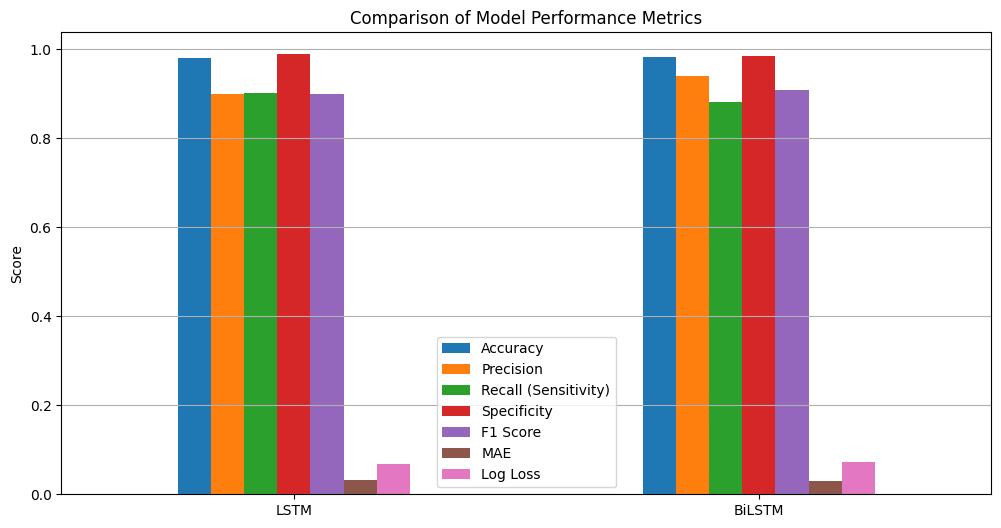

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame([lstm_results, bilstm_results],
                          index=["LSTM", "BiLSTM"])

results_df.plot(kind='bar', figsize=(12,6))
plt.title("Comparison of Model Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


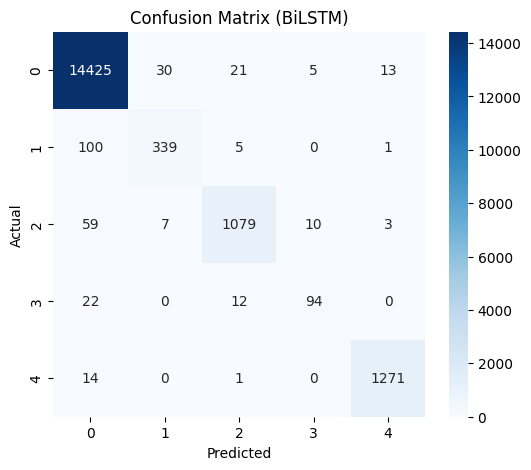

In [40]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_bilstm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (BiLSTM)")
plt.show()


In [41]:
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Activation
)

def cnn_feature_extractor(x):
    x = Conv1D(64, 6, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(3, strides=2, padding='same')(x)

    x = Conv1D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2, strides=2, padding='same')(x)

    x = Conv1D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2, strides=2, padding='same')(x)

    return x

In [42]:
from tensorflow.keras.layers import LSTM

inputs = Input(shape=(187,1))
x = cnn_feature_extractor(inputs)
x = LSTM(64, return_sequences=False)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)

cnn_lstm_model = Model(inputs, outputs)
cnn_lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [43]:
from tensorflow.keras.layers import Bidirectional

inputs = Input(shape=(187,1))
x = cnn_feature_extractor(inputs)
x = Bidirectional(LSTM(64))(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)

cnn_bilstm_model = Model(inputs, outputs)
cnn_bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [44]:
from tensorflow.keras.layers import Add

def residual_block(x, filters=64):
    shortcut = x

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x


In [45]:
inputs = Input(shape=(187,1))

x = Conv1D(64, 6, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(3, strides=2, padding='same')(x)

x = residual_block(x)
x = MaxPooling1D(2, strides=2, padding='same')(x)

x = residual_block(x)
x = MaxPooling1D(2, strides=2, padding='same')(x)

x = LSTM(64)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)

resnet_lstm_model = Model(inputs, outputs)
resnet_lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [46]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense

inputs = Input(shape=(187,1))
x = cnn_feature_extractor(inputs)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
models = {
    "CNN": cnn_model,
    "CNN-LSTM": cnn_lstm_model,
    "CNN-BiLSTM": cnn_bilstm_model,
    "ResNet-LSTM": resnet_lstm_model
}

histories = {}
for name, model in models.items():
    print(f"Training {name}")
    histories[name] = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=128,
        verbose=1
    )


Training CNN
Epoch 1/20


I0000 00:00:1767714689.260175      71 service.cc:152] XLA service 0x7d05338f53d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767714689.260218      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 48/548 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8103 - loss: 0.6353

I0000 00:00:1767714692.512744      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


548/548 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9289 - loss: 0.2507 - val_accuracy: 0.8264 - val_loss: 0.4722
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9747 - loss: 0.0907 - val_accuracy: 0.9740 - val_loss: 0.0896
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.0710 - val_accuracy: 0.9763 - val_loss: 0.0860
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9815 - loss: 0.0621 - val_accuracy: 0.9824 - val_loss: 0.0630
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9840 - val_loss: 0.0579
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9870 - loss: 0.0432 - val_accuracy: 0.9833 - val_loss: 0.0588
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9875 - loss: 0.0398 - val_accuracy: 0.9832 - val_loss: 0.0623
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9892 - loss: 0.0350 - val_accuracy: 0.9823 - va

In [48]:
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Add

def residual_block(x, filters=64):
    shortcut = x

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)

    return x

In [49]:
from tensorflow.keras.layers import (
    Input, MaxPooling1D, Bidirectional, LSTM, Dense
)
from tensorflow.keras.models import Model

inputs = Input(shape=(187, 1))

# Initial convolution
x = Conv1D(64, 6, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

# Residual blocks
x = residual_block(x, filters=64)
x = MaxPooling1D(pool_size=2, strides=2, padding='same')(x)

x = residual_block(x, filters=64)
x = MaxPooling1D(pool_size=2, strides=2, padding='same')(x)

# 🔥 BiLSTM instead of LSTM
x = Bidirectional(LSTM(64))(x)

# Dense layers
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

outputs = Dense(5, activation='softmax')(x)

resnet_bilstm_model = Model(inputs, outputs)

In [50]:
resnet_bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_bilstm_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 187, 64)   │        448 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 187, 64)   │        256 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 187, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 94, 64)    │          0 │ activation_22[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 94, 64)    │     12,352 │ max_pooling1d_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 64)    │        256 │ conv1d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 94, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 94, 64)    │     12,352 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 64)    │        256 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 94, 64)    │          0 │ max_pooling1d_18… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 94, 64)    │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 47, 64)    │          0 │ activation_24[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 47, 64)    │     12,352 │ max_pooling1d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 47, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 47, 64)    │     12,352 │ activation_25[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 127,685 (498.77 KB)

 Trainable params: 127,045 (496.27 KB)

 Non-trainable params: 640 (2.50 KB)

In [51]:
history_resnet_bilstm = resnet_bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9085 - loss: 0.3282 - val_accuracy: 0.7285 - val_loss: 0.7503
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9700 - loss: 0.1093 - val_accuracy: 0.9701 - val_loss: 0.1027
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9752 - loss: 0.0884 - val_accuracy: 0.9754 - val_loss: 0.0917
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9807 - loss: 0.0705 - val_accuracy: 0.9731 - val_loss: 0.0983
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9827 - loss: 0.0603 - val_accuracy: 0.9789 - val_loss: 0.0765
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9845 - loss: 0.0549 - val_accuracy: 0.9822 - val_loss: 0.0622
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9852 - loss: 0.0504 - val_accuracy: 0.9825 - val_loss: 0.0647
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9859 - loss: 0.0472 - val_acc

In [52]:
histories["ResNet-BiLSTM"] = history_resnet_bilstm

In [53]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, mean_absolute_error, log_loss
)

y_prob = resnet_bilstm_model.predict(X_val)
y_pred = np.argmax(y_prob, axis=1)



548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, mean_absolute_error, log_loss
)

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec = []
    for i in range(len(cm)):
        TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        FP = cm[:,i].sum() - cm[i,i]
        spec.append(TN / (TN + FP))
    return np.mean(spec)


In [55]:
results = {}

for name, model in models.items():
    y_prob = model.predict(X_val)
    y_pred = np.argmax(y_prob, axis=1)

    results[name] = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, average='macro'),
        "Recall": recall_score(y_val, y_pred, average='macro'),
        "Specificity": specificity_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred, average='macro'),
        "MAE": mean_absolute_error(y_val, y_pred),
        "Log Loss": log_loss(y_val, y_prob)
    }


548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [56]:
results["ResNet-BiLSTM"] = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred, average='macro'),
    "Recall": recall_score(y_val, y_pred, average='macro'),
    "Specificity": specificity_score(y_val, y_pred),
    "F1 Score": f1_score(y_val, y_pred, average='macro'),
    "MAE": mean_absolute_error(y_val, y_pred),
    "Log Loss": log_loss(y_val, y_prob)
}

In [57]:
results

{'CNN': {'Accuracy': 0.9800125635314945,
  'Precision': 0.9022410160689496,
  'Recall': 0.9002847946864845,
  'Specificity': np.float64(0.9898276232504278),
  'F1 Score': 0.900612040423117,
  'MAE': 0.036320027411341445,
  'Log Loss': 0.07923571624396565},
 'CNN-LSTM': {'Accuracy': 0.9842384786705499,
  'Precision': 0.9381864330245688,
  'Recall': 0.8947513032052159,
  'Specificity': np.float64(0.9881074535820685),
  'F1 Score': 0.9140097054768453,
  'MAE': 0.02712580663582891,
  'Log Loss': 0.05463838753598486},
 'CNN-BiLSTM': {'Accuracy': 0.9864656501627549,
  'Precision': 0.9368596277007363,
  'Recall': 0.9129862763260481,
  'Specificity': np.float64(0.9905936081322547),
  'F1 Score': 0.9244888138208017,
  'MAE': 0.022728570612757695,
  'Log Loss': 0.049811361704159805},
 'ResNet-LSTM': {'Accuracy': 0.982296841985038,
  'Precision': 0.8962419811455572,
  'Recall': 0.917229529047231,
  'Specificity': np.float64(0.9899537619488825),
  'F1 Score': 0.9062907406500111,
  'MAE': 0.0295242

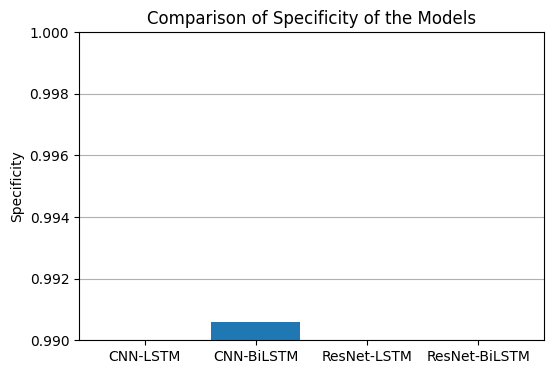

In [58]:
import matplotlib.pyplot as plt

models = ["CNN-LSTM", "CNN-BiLSTM", "ResNet-LSTM", "ResNet-BiLSTM"]
specificity = [
    results["CNN-LSTM"]["Specificity"],
    results["CNN-BiLSTM"]["Specificity"],
    results["ResNet-LSTM"]["Specificity"],
    results["ResNet-BiLSTM"]["Specificity"]
]

plt.figure(figsize=(6,4))
plt.bar(models, specificity)
plt.ylabel("Specificity")
plt.title("Comparison of Specificity of the Models")
plt.ylim(0.99, 1.0)
plt.grid(axis="y")
plt.show()

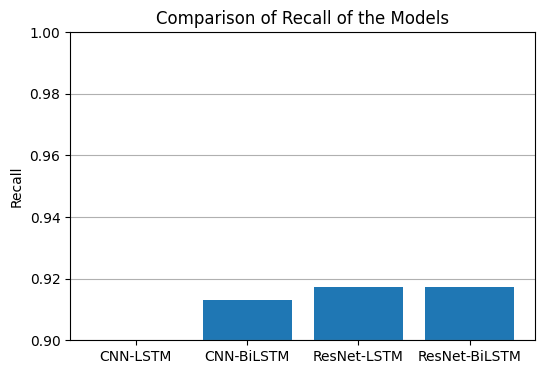

In [59]:
recall = [
    results["CNN-LSTM"]["Recall"],
    results["CNN-BiLSTM"]["Recall"],
    results["ResNet-LSTM"]["Recall"],
    results["ResNet-BiLSTM"]["Recall"]
]

plt.figure(figsize=(6,4))
plt.bar(models, recall)
plt.ylabel("Recall")
plt.title("Comparison of Recall of the Models")
plt.ylim(0.90, 1.0)
plt.grid(axis="y")
plt.show()

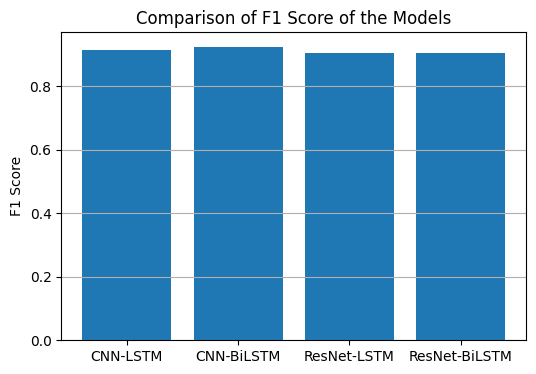

In [60]:
f1 = [
    results["CNN-LSTM"]["F1 Score"],
    results["CNN-BiLSTM"]["F1 Score"],
    results["ResNet-LSTM"]["F1 Score"],
    results["ResNet-BiLSTM"]["F1 Score"]
]

plt.figure(figsize=(6,4))
plt.bar(models, f1)
plt.ylabel("F1 Score")
plt.title("Comparison of F1 Score of the Models")
plt.grid(axis="y")
plt.show()

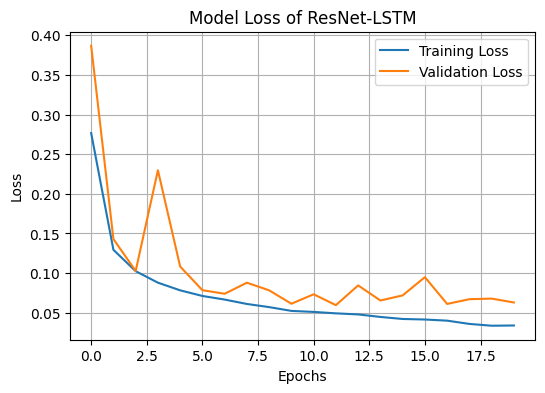

In [61]:
plt.figure(figsize=(6,4))
plt.plot(histories["ResNet-LSTM"].history["loss"], label="Training Loss")
plt.plot(histories["ResNet-LSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of ResNet-LSTM")
plt.legend()
plt.grid()
plt.show()

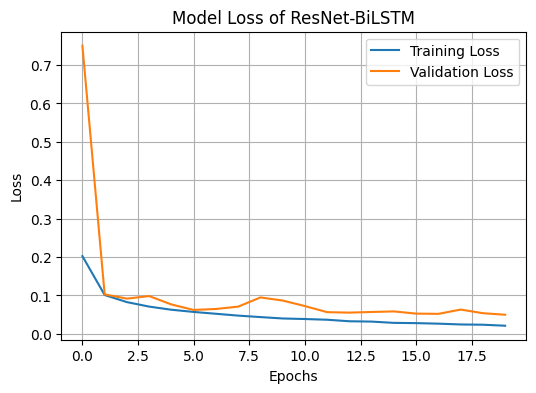

In [62]:
plt.figure(figsize=(6,4))
plt.plot(histories["ResNet-BiLSTM"].history["loss"], label="Training Loss")
plt.plot(histories["ResNet-BiLSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of ResNet-BiLSTM")
plt.legend()
plt.grid()
plt.show()

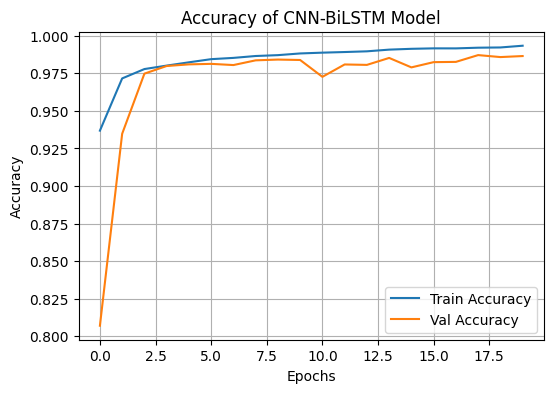

In [63]:
plt.figure(figsize=(6,4))
plt.plot(histories["CNN-BiLSTM"].history["accuracy"], label="Train Accuracy")
plt.plot(histories["CNN-BiLSTM"].history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy of CNN-BiLSTM Model")
plt.legend()
plt.grid()
plt.show()

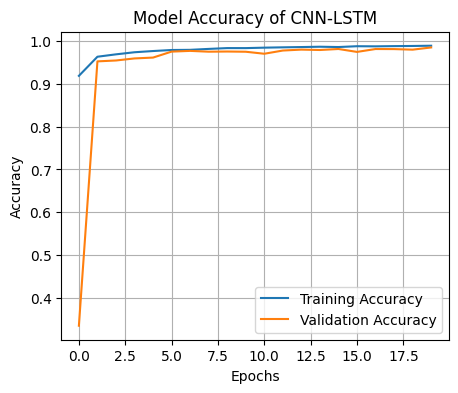

In [64]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-LSTM"].history["accuracy"], label="Training Accuracy")
plt.plot(histories["CNN-LSTM"].history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy of CNN-LSTM")
plt.legend()
plt.grid()
plt.show()

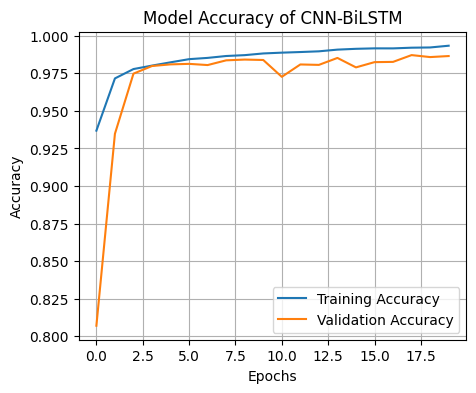

In [65]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-BiLSTM"].history["accuracy"], label="Training Accuracy")
plt.plot(histories["CNN-BiLSTM"].history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy of CNN-BiLSTM")
plt.legend()
plt.grid()
plt.show()

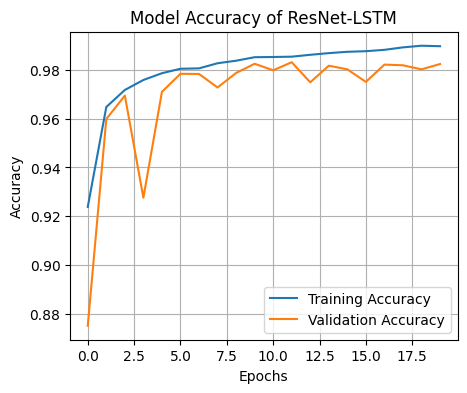

In [66]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-LSTM"].history["accuracy"], label="Training Accuracy")
plt.plot(histories["ResNet-LSTM"].history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy of ResNet-LSTM")
plt.legend()
plt.grid()
plt.show()

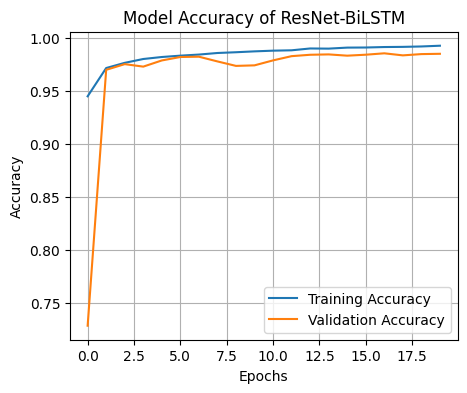

In [67]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-BiLSTM"].history["accuracy"], label="Training Accuracy")
plt.plot(histories["ResNet-BiLSTM"].history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy of ResNet-BiLSTM")
plt.legend()
plt.grid()
plt.show()

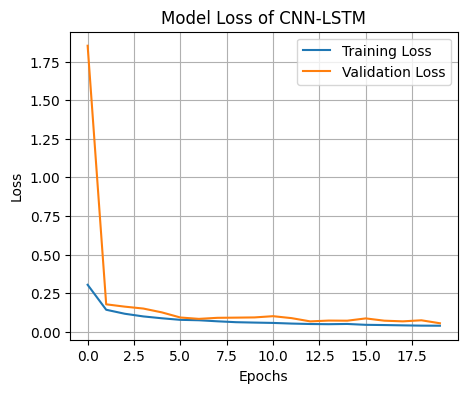

In [68]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-LSTM"].history["loss"], label="Training Loss")
plt.plot(histories["CNN-LSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of CNN-LSTM")
plt.legend()
plt.grid()
plt.show()

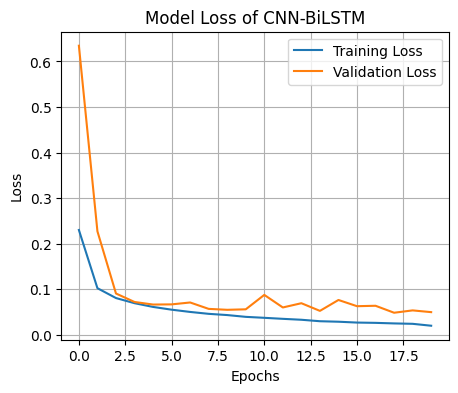

In [69]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-BiLSTM"].history["loss"], label="Training Loss")
plt.plot(histories["CNN-BiLSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of CNN-BiLSTM")
plt.legend()
plt.grid()
plt.show()

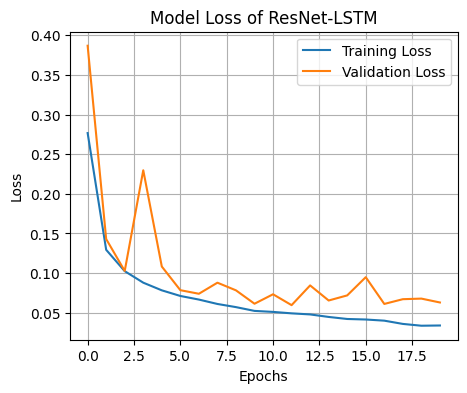

In [70]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-LSTM"].history["loss"], label="Training Loss")
plt.plot(histories["ResNet-LSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of ResNet-LSTM")
plt.legend()
plt.grid()
plt.show()

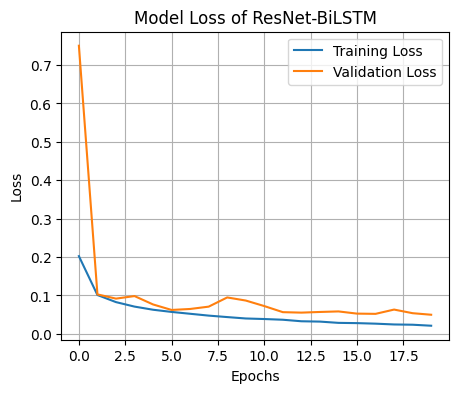

In [71]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-BiLSTM"].history["loss"], label="Training Loss")
plt.plot(histories["ResNet-BiLSTM"].history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss of ResNet-BiLSTM")
plt.legend()
plt.grid()
plt.show()

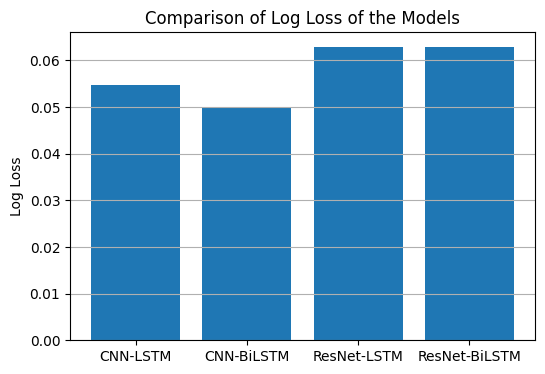

In [72]:
import matplotlib.pyplot as plt

log_loss_vals = [
    results["CNN-LSTM"]["Log Loss"],
    results["CNN-BiLSTM"]["Log Loss"],
    results["ResNet-LSTM"]["Log Loss"],
    results["ResNet-BiLSTM"]["Log Loss"]
]

plt.figure(figsize=(6,4))
plt.bar(models, log_loss_vals)
plt.ylabel("Log Loss")
plt.title("Comparison of Log Loss of the Models")
plt.grid(axis="y")
plt.show()

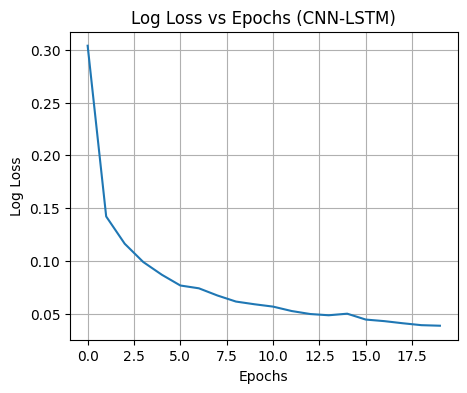

In [73]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-LSTM"].history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Epochs (CNN-LSTM)")
plt.grid()
plt.show()

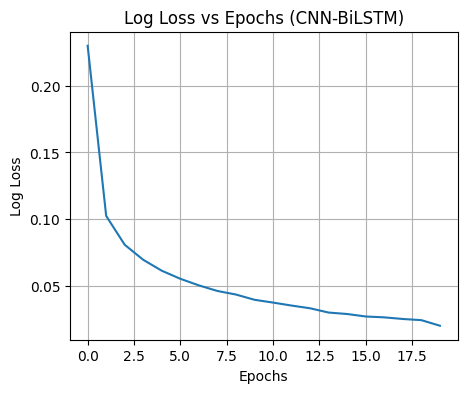

In [74]:
plt.figure(figsize=(5,4))
plt.plot(histories["CNN-BiLSTM"].history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Epochs (CNN-BiLSTM)")
plt.grid()
plt.show()

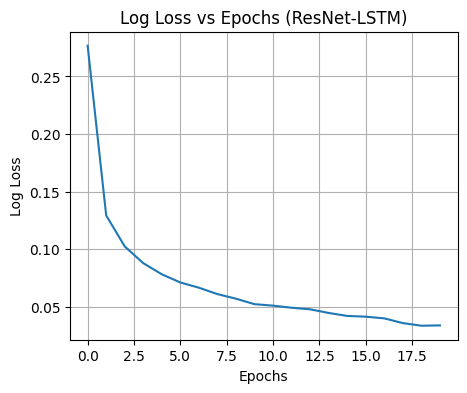

In [75]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-LSTM"].history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Epochs (ResNet-LSTM)")
plt.grid()
plt.show()

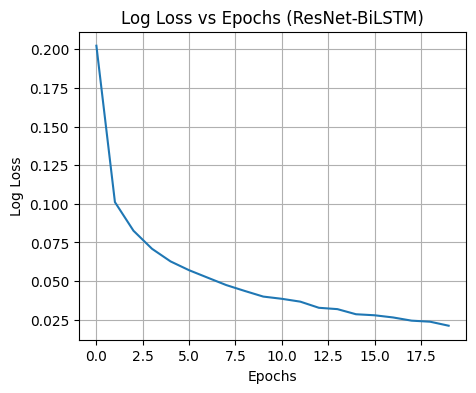

In [76]:
plt.figure(figsize=(5,4))
plt.plot(histories["ResNet-BiLSTM"].history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Epochs (ResNet-BiLSTM)")
plt.grid()
plt.show()

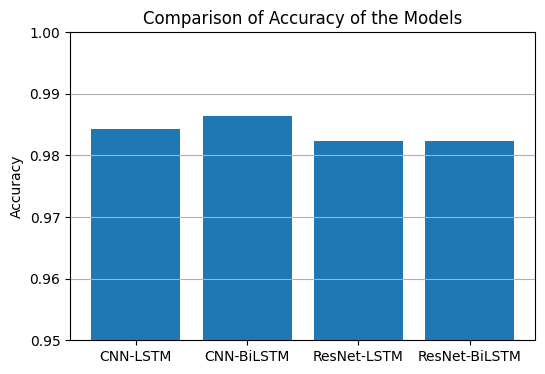

In [77]:
accuracy_vals = [
    results["CNN-LSTM"]["Accuracy"],
    results["CNN-BiLSTM"]["Accuracy"],
    results["ResNet-LSTM"]["Accuracy"],
    results["ResNet-BiLSTM"]["Accuracy"]
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy_vals)
plt.ylabel("Accuracy")
plt.title("Comparison of Accuracy of the Models")
plt.ylim(0.95, 1.0)
plt.grid(axis="y")
plt.show()

In [78]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch

def extract_ts_features(signal, fs=125):
    features = {}

    # Time-domain
    features["mean"] = np.mean(signal)
    features["std"] = np.std(signal)
    features["rms"] = np.sqrt(np.mean(signal**2))
    features["skew"] = skew(signal)
    features["kurtosis"] = kurtosis(signal)
    features["energy"] = np.sum(signal**2)

    # Frequency-domain
    freqs, psd = welch(signal, fs=fs)
    features["dominant_freq"] = freqs[np.argmax(psd)]
    features["spectral_entropy"] = -np.sum(psd * np.log(psd + 1e-12))

    return features


In [79]:
import pandas as pd

X_features = pd.DataFrame(
    [extract_ts_features(x) for x in X.values]
)

X_features.head()


/usr/local/lib/python3.12/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 187, using nperseg = 187
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


,mean,std,rms,skew,kurtosis,energy,dominant_freq,spectral_entropy
0,0.098419,0.176073,0.201713,3.546201,13.625459,7.608654,1.336898,0.389335
1,0.090010,0.159722,0.183338,3.835006,16.261444,6.285631,2.673797,0.270876
2,0.062104,0.138769,0.152032,4.324592,22.166909,4.322286,0.668449,0.228431
3,0.084084,0.160821,0.181476,3.477492,13.691750,6.158557,1.336898,0.338424
4,0.116567,0.186151,0.219637,3.109726,10.238896,9.020939,1.336898,0.304096


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96     14494
         1.0       0.80      0.40      0.54       445
         2.0       0.85      0.62      0.72      1158
         3.0       0.79      0.35      0.49       128
         4.0       0.89      0.79      0.84      1286

    accuracy                           0.93     17511
   macro avg       0.85      0.63      0.71     17511
weighted avg       0.92      0.93      0.92     17511

